# Requirements
- scipp
- scippneutron
- python-graphviz (or graphviz)

# Links

[energy_transfer_direct_from_tof](https://scipp.github.io/scippneutron/generated/modules/scippneutron.conversion.tof.energy_transfer_direct_from_tof.html#scippneutron.conversion.tof.energy_transfer_direct_from_tof)


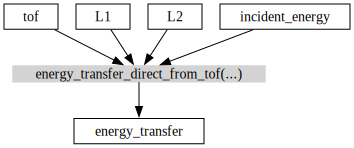

In [33]:
import scipp as sc
from scippneutron.conversion import graph

inelastic_tof_graph = graph.tof.direct_inelastic('tof')
sc.show_graph(inelastic_tof_graph)

In [67]:
da = sc.DataArray(data=sc.ones(dims=['event'], shape=(30,)), coords={
    'tof': sc.linspace(dim='event', start=5, stop=10, unit='microsecond', num=30),
    'L1': sc.scalar(60., unit='m'),
    'L2': sc.scalar(0.5, unit='m'),
})

da

<scipp.DataArray>
Dimensions: Sizes[event:30, ]
Coordinates:
* L1                        float64              [m]  ()  60
* L2                        float64              [m]  ()  0.5
* tof                       float64            [µs]  (event)  [5, 5.17241, ..., 9.82759, 10]
Data:
                            float64  [dimensionless]  (event)  [1, 1, ..., 1, 1]

In [68]:
tof_boundaries = sc.linspace(dim='tof', start=5, stop=10, unit='microsecond', num=5)
sliced = da.bin(tof=tof_boundaries)
sliced.coords['incident_energy'] = sc.linspace(dim='tof', start=100, stop=200, unit='MeV', num=4)
sliced = sliced.drop_coords('tof')
sliced

<scipp.DataArray>
Dimensions: Sizes[tof:4, ]
Coordinates:
* L1                        float64              [m]  ()  60
* L2                        float64              [m]  ()  0.5
* incident_energy           float64            [MeV]  (tof)  [100, 133.333, 166.667, 200]
Data:
                          DataArrayView        <no unit>  (tof)  binned data: dim='event', content=DataArray(
          dims=(event: 29),
          data=float64[dimensionless],
          coords={'tof':float64[µs]})

In [69]:
energy_transfer_da = sliced.transform_coords('energy_transfer', graph=inelastic_tof_graph, rename_dims=True)
energy_transfer_da

<scipp.DataArray>
Dimensions: Sizes[energy_transfer:4, ]
Coordinates:
  L1                        float64              [m]  ()  60
  L2                        float64              [m]  ()  0.5
  incident_energy           float64            [MeV]  (energy_transfer)  [100, 133.333, 166.667, 200]
Data:
                          DataArrayView        <no unit>  (energy_transfer)  binned data: dim='event', content=DataArray(
          dims=(event: 29),
          data=float64[dimensionless],
          coords={'tof':float64[µs], 'energy_transfer':float64[MeV]})

In [70]:
energy_transfer_da.bins.concat().value

<scipp.DataArray>
Dimensions: Sizes[event:29, ]
Coordinates:
* energy_transfer           float64            [MeV]  (event)  [99.9999, 99.9999, ..., 200, 200]
  tof                       float64            [µs]  (event)  [5, 5.17241, ..., 9.65517, 9.82759]
Data:
                            float64  [dimensionless]  (event)  [1, 1, ..., 1, 1]